In [ ]:
import numpy as np
import tensorflow as tf
from keras import layers, Model, callbacks
import ruptures as rpt
import matplotlib.pyplot as plt
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ecod import ECOD
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.kde import KDE
from scipy.stats import kurtosis, skew, chi2, entropy

class T2Detector:
    """Hotelling's T-squared multivariate statistical control detector."""
    def __init__(self, alpha=0.005):
        self.alpha = alpha
        self.mean_ = None
        self.cov_ = None
        self.inv_cov_ = None
        self.threshold_ = None

    def fit(self, X, y=None):
        self.mean_ = np.mean(X, axis=0)
        self.cov_ = np.cov(X, rowvar=False)
        if np.ndim(self.cov_) == 0:
            self.cov_ = np.array([[self.cov_]])
        self.inv_cov_ = np.linalg.pinv(self.cov_)
        df = X.shape[1]
        self.threshold_ = chi2.ppf(1 - self.alpha, df=df)
        return self

    def predict(self, X):
        diff = X - self.mean_
        md2 = np.sum(diff @ self.inv_cov_ * diff, axis=1)
        return (md2 > self.threshold_).astype(int)

class BoxplotOutlier1D:
    """1D boxplot outlier detector (IQR method)."""
    def fit(self, X, y=None):
        X = np.asarray(X)
        x = X[:, 0] if (X.ndim == 2 and X.shape[1] == 1) else X.ravel()
        q1, q3 = np.percentile(x, [25, 75])
        iqr = q3 - q1
        self.low_ = q1 - 1.5 * iqr
        self.high_ = q3 + 1.5 * iqr
        return self

    def predict(self, X):
        X = np.asarray(X)
        x = X[:, 0] if (X.ndim == 2 and X.shape[1] == 1) else X.ravel()
        out = (x < self.low_) | (x > self.high_)
        return out.astype(int)

class VSCOUT:
    """
    Variational Self-Correcting Outlier Uncovering Technique (VSCOUT).
    Combines ARD-VAE, PELT changepoint detection, and ensemble methods for anomaly detection.
    """
    def __init__(
        self,
        encoder_neurons=(64,), decoder_neurons=(64,), latent_dim=32,
        learning_rate=1e-4, alpha=0.005, penalty=40, kl_threshold=1,
        flag_rule="any", n_jobs=1, kurtosis_threshold=5.0
    ):
        self.encoder_neurons = encoder_neurons
        self.decoder_neurons = decoder_neurons
        self.latent_dim = latent_dim
        self.learning_rate = learning_rate
        self.alpha = alpha
        self.penalty = penalty
        self.kl_threshold = kl_threshold
        self.flag_rule = flag_rule
        self.n_jobs = n_jobs
        self.kurtosis_threshold = kurtosis_threshold

        self.vae = None
        self.encoder = None
        self.decoder = None
        self.latent_encoder = None
        self.orig_dim = None
        self._X_train = None
        self.z_inliers = None
        self.change_points = None
        self.inlier_mask = None
        self.kl_divs = None
        self.relevant_latents = None
        self.ere1_threshold = None
        self.latent_mean_inlier = None
        self.latent_cov_inlier = None
        self.t2_threshold = None
        self.base_detectors = None

    @staticmethod
    def suggest_flag_rule(X):
        """Analyzes data distribution to suggest 'any' or 'majority' voting for the ensemble."""
        X = np.nan_to_num(np.asarray(X))
        avg_kurt = np.mean(np.abs(kurtosis(X, axis=0, fisher=False)))
        avg_skew = np.mean(np.abs(skew(X, axis=0)))
        n_samples, n_features = X.shape
        entropies = [entropy(np.histogram(X[:,i], bins=10)[0] + 1e-8) for i in range(n_features)]
        avg_entropy = np.mean(entropies)
        
        multimodal = False
        try:
            from scipy.signal import find_peaks
            for i in range(n_features):
                counts, _ = np.histogram(X[:,i], bins=20)
                peaks, props = find_peaks(counts, height=np.max(counts)*0.4, prominence=np.max(counts)*0.3, distance=2)
                if len(peaks) > 1:
                    sorted_h = np.sort(props['peak_heights'])
                    if sorted_h[-2] > 0.5 * sorted_h[-1]:
                        multimodal = True
                        break
        except Exception: pass

        if avg_kurt > 5 or avg_skew > 5 or avg_entropy > 2.0:
            return "any"
        return "majority"

    def _build_model(self, X, force_structure=False):
        if self.flag_rule is None:
            self.flag_rule = self.suggest_flag_rule(X)

        enc_in = layers.Input(shape=(X.shape[1],), name="enc_in")
        h = enc_in
        for neurons in self.encoder_neurons:
            h = layers.Dense(neurons, activation="relu", kernel_initializer="he_normal")(h)
            h = layers.BatchNormalization()(h)
            h = layers.Dropout(0.2)(h)
        
        z_mean = layers.Dense(self.latent_dim, name="z_mean")(h)
        z_log_var = layers.Dense(self.latent_dim, name="z_log_var")(h)

        def sample(args):
            m, lv = args
            return m + tf.exp(0.5 * lv) * tf.random.normal(tf.shape(m))
        
        z = layers.Lambda(sample, name="z")([z_mean, z_log_var])
        self.encoder = Model(enc_in, [z_mean, z_log_var, z], name="encoder")

        lat_in = layers.Input(shape=(self.latent_dim,), name="z_sampling")
        h2 = lat_in
        for neurons in self.decoder_neurons:
            h2 = layers.Dense(neurons, activation="relu", kernel_initializer="he_normal")(h2)
            h2 = layers.BatchNormalization()(h2)
            h2 = layers.Dropout(0.2)(h2)
        
        dec_out = layers.Dense(X.shape[1], activation="linear")(h2)
        self.decoder = Model(lat_in, dec_out, name="decoder")

        class ARDVAE(Model):
            def __init__(self, encoder, decoder):
                super().__init__()
                self.encoder, self.decoder = encoder, decoder
                self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
                self.recon_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
                self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

            def call(self, inputs, training=False):
                _, _, z = self.encoder(inputs, training=training)
                return self.decoder(z, training=training)

            @property
            def metrics(self):
                return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

            def train_step(self, data):
                x = data[0] if isinstance(data, tuple) else data
                with tf.GradientTape() as tape:
                    z_mean, z_log_var, z = self.encoder(x, training=True)
                    x_recon = self.decoder(z, training=True)
                    recon_loss = tf.reduce_sum(tf.square(x - x_recon), axis=1)
                    kl_loss = 0.5 * tf.reduce_sum(-1 - z_log_var + tf.square(z_mean) + tf.exp(z_log_var), axis=1)
                    total_loss = tf.reduce_mean(recon_loss + kl_loss)
                
                grads = tape.gradient(total_loss, self.trainable_variables)
                self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
                self.total_loss_tracker.update_state(total_loss)
                self.recon_loss_tracker.update_state(tf.reduce_mean(recon_loss))
                self.kl_loss_tracker.update_state(tf.reduce_mean(kl_loss))
                return {m.name: m.result() for m in self.metrics}

            def compute_latent_statistics(self, z_means, inlier_mask):
                z_in = z_means[inlier_mask]
                self.latent_mean_normal = np.median(z_in, axis=0)
                self.latent_var_normal = (np.median(np.abs(z_in - self.latent_mean_normal), axis=0) + 1e-6) ** 2

        self.vae = ARDVAE(self.encoder, self.decoder)
        self.latent_encoder = Model(self.encoder.input, self.encoder.get_layer("z_mean").output)

    def _fit_ensemble(self, z_mean_relevant):
        z = np.asarray(z_mean_relevant)
        detectors = []
        if z.ndim == 2 and z.shape[1] == 1:
            detectors.append(BoxplotOutlier1D())
        
        detectors.extend([
            IForest(), LOF(), HBOS(), ECOD(), KNN(n_neighbors=2), KDE(),
            T2Detector(alpha=self.alpha)
        ])
        for clf in detectors:
            clf.fit(z_mean_relevant)
        self.base_detectors = detectors

    def _ensemble_predict(self, z_mean_relevant, rule='majority'):
        base_preds = np.array([clf.predict(z_mean_relevant) for clf in self.base_detectors])
        votes = np.sum(base_preds, axis=0)
        if rule == 'majority':
            return votes >= (len(self.base_detectors) // 2 + 1)
        return np.any(base_preds, axis=0)

    def fit(self, X_train, epochs=30, batch_size=32, verbose=1):
        """Fits the model using a two-stage approach to filter outliers before final training."""
        self.orig_dim = X_train.shape[1]
        self._X_train = X_train.copy()
        self._build_model(X_train)
        
        early_stop = callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
        self.vae.compile(optimizer=tf.keras.optimizers.Adam(self.learning_rate))
        
        # Stage 1: Initial training to identify noise/changepoints
        self.vae.fit(X_train, epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=[early_stop])
        
        initial_enc_w = self.encoder.get_weights()
        initial_dec_w = self.decoder.get_weights()
        
        z_mean, z_log_var, _ = self.encoder.predict(X_train, batch_size=batch_size)
        kl_divs = np.mean(0.5 * (-1 - z_log_var + np.square(z_mean) + np.exp(z_log_var)), axis=0)
        relevant_indices = np.where(kl_divs > self.kl_threshold)[0]
        self.relevant_latents = relevant_indices if len(relevant_indices) > 0 else np.array([0])
        
        z_relevant = z_mean[:, self.relevant_latents]
        l2_norm = np.linalg.norm(z_relevant, axis=1)
        self.change_points = rpt.Pelt(model="rbf").fit(l2_norm.reshape(-1, 1)).predict(pen=self.penalty)
        
        cp_mask = np.zeros(len(z_mean), dtype=bool)
        if len(self.change_points) > 0:
            cp_mask[self.change_points[0]:] = True
            
        self._fit_ensemble(z_relevant)
        suod_mask = self._ensemble_predict(z_relevant, rule=self.flag_rule)
        
        self.inlier_mask = ~(np.logical_or(cp_mask, suod_mask))
        X_inliers = X_train[self.inlier_mask]
        
        # Stage 2: Refined training on inliers
        self._build_model(X_inliers, force_structure=True)
        self.vae.compile(optimizer=tf.keras.optimizers.Adam(self.learning_rate))
        self.vae.fit(X_inliers, epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=[early_stop])
        
        z_in_mean, _, _ = self.encoder.predict(X_inliers, batch_size=batch_size)
        self.z_inliers = z_in_mean[:, self.relevant_latents]
        self.latent_mean_inlier = np.mean(self.z_inliers, axis=0)
        
        cov = np.cov(self.z_inliers, rowvar=False)
        self.latent_cov_inlier = np.array([[cov]]) if np.ndim(cov) == 0 else cov
        self.t2_threshold = chi2.ppf(1 - self.alpha, df=len(self.relevant_latents))
        self._fit_ensemble(self.z_inliers)

    def is_outlier(self, data, batch_size=32):
        """Returns outlier masks based on ensemble, T2, changepoints, and reconstruction error."""
        z_mean, z_log_var, z_sample = self.encoder.predict(data, batch_size=batch_size)
        z_rel = z_mean[:, self.relevant_latents]

        cp_mask = np.zeros(len(z_rel), dtype=bool)
        if self.change_points and len(self.change_points) > 0:
            cp_mask[self.change_points[0]:] = True

        suod_mask = self._ensemble_predict(z_rel, rule=self.flag_rule)
        
        inv_cov = np.linalg.pinv(self.latent_cov_inlier)
        diff = z_rel - self.latent_mean_inlier
        mahal_sq = np.sum(diff @ inv_cov * diff, axis=1)
        t2_mask = mahal_sq > self.t2_threshold

        x_recon = self.decoder.predict(z_sample, batch_size=batch_size)
        recon_errors = np.sum((data - x_recon) ** 2, axis=1)
        # Threshold is the 95th percentile of errors seen during training inliers
        recon_threshold = np.percentile(np.sum((self._X_train[self.inlier_mask] - 
                                         self.decoder.predict(self.encoder.predict(self._X_train[self.inlier_mask])[2]))**2, axis=1), 95)
        recon_mask = recon_errors > recon_threshold

        votes = np.stack([suod_mask, t2_mask, cp_mask, recon_mask], axis=1)
        final_outlier = np.sum(votes, axis=1) >= 2
        
        return final_outlier, cp_mask, suod_mask, t2_mask, recon_mask, mahal_sq, self.t2_threshold, recon_threshold

    def plot_control_chart(self, data, batch_size=32, phase="Phase I", show_plot=True):
            """
            Generates statistical control charts for Phase I (cleaning/baseline) or Phase II (real-time monitoring).
            """
            x_vals = np.arange(len(data))

            if phase == "Phase I":
                is_out, cp, suod, t2, rec, m2, thresh, _ = self.is_outlier(data, batch_size)
                
                if show_plot:
                    plt.figure(figsize=(16, 7))
                    # Plot continuous distance line
                    plt.plot(x_vals, m2, color='gray', linestyle='-', linewidth=1, alpha=0.5, label='Mahalanobis²')
                    
                    # Markers for specific detection sources
                    plt.plot(x_vals[is_out], m2[is_out], 'ro', markersize=8, label='Out-of-Control')
                    plt.plot(x_vals[cp], m2[cp], 'D', markersize=4, linestyle='None', label='ChangePoint Flag')
                    plt.plot(x_vals[suod], m2[suod], 'kx', markersize=4, linestyle='None', label='Ensemble Flag')
                    plt.plot(x_vals[t2], m2[t2], 'g+', markersize=4, linestyle='None', label='T² Flag')
                    plt.plot(x_vals[rec], m2[rec], 'y^', markersize=4, linestyle='None', label='Reconstruction Flag')
                    
                    plt.axhline(y=thresh, color='green', linestyle='--', linewidth=2, label='T² Threshold')
                    
                    if self.change_points is not None:
                        for p in self.change_points:
                            plt.axvline(p, color='magenta', linestyle=':', alpha=0.6, label='Changepoint' if p == self.change_points[0] else "")
                    
                    plt.title('VSCOUT: Phase I Control Chart')
                    plt.xlabel('Sample Index')
                    plt.ylabel('Mahalanobis² Value')
                    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
                    plt.grid(True, alpha=0.3)
                    plt.tight_layout()
                    plt.show()
                return is_out

            elif phase == "Phase II":
                    z_m, _, _ = self.encoder.predict(data, batch_size=batch_size)
                    z_rel = z_m[:, self.relevant_latents]
                    diff = z_rel - self.latent_mean_inlier
                    T2 = np.sum(diff @ np.linalg.pinv(self.latent_cov_inlier) * diff, axis=1)
                    out_mask = T2 > self.t2_threshold
                    
                    if show_plot:
                        plt.figure(figsize=(16, 7))
                        
                        # Consistent gray path for distances
                        plt.plot(x_vals, T2, color='gray', linestyle='-', linewidth=1, alpha=0.5, label='Mahalanobis² (T²)')
                        
                        # Consistent Out-of-control marker (Red Circle)
                        plt.plot(x_vals[out_mask], T2[out_mask], 'ro', markersize=8, label='Out-of-Control')
                        
                        # Consistent green threshold line
                        plt.axhline(y=self.t2_threshold, color='green', linestyle='--', linewidth=2, label='T² Threshold')
                        
                        plt.title('VSCOUT: Phase II Latent Space Monitoring')
                        plt.xlabel('Sample Index')
                        plt.ylabel('Hotelling T² Distance')
                        plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
                        plt.grid(True, alpha=0.3)
                        plt.tight_layout()
                        plt.show()
                    return out_mask
                
            else:
                raise ValueError("phase must be 'Phase I' or 'Phase II'")

    @property
    def latent_mean(self): return self.latent_mean_inlier

    @property
    def latent_cov(self): return self.latent_cov_inlier


In [19]:
import numpy as np
from scipy.stats import norm

def compute_correlation_matrix(X):
    """Standardized correlation matrix from data"""
    S = np.cov(X, rowvar=False)
    D = np.diag(np.diag(S))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(S)))
    R = D_inv_sqrt @ S @ D_inv_sqrt
    return R, S

def compute_traces(R, p, m):
    """Robust estimates of trace(ρ²) and trace(ρ³)"""
    tr_r2 = np.trace(R @ R) - p**2 / m
    tr_r3 = np.trace(R @ R @ R) - 3*p/m * np.trace(R @ R) + 2 * (p**3) / (m**2)
    return tr_r2, tr_r3

def cornish_fisher_threshold(z_alpha, tr_r2, tr_r3):
    return z_alpha + (4 * tr_r3 * (z_alpha**2 - 1)) / (3 * (2 * tr_r2)**1.5)

def initial_mdp_subset(X, h):
    """Find subset of h samples with minimum diagonal determinant"""
    from itertools import combinations
    m = X.shape[0]
    best_det = np.inf
    best_subset = None
    for idx in combinations(range(m), h):
        subset = X[list(idx)]
        S = np.cov(subset, rowvar=False)
        diag_det = np.prod(np.diag(S))
        if diag_det < best_det:
            best_det = diag_det
            best_subset = subset
    return best_subset

from sklearn.covariance import MinCovDet

def fast_mdp_subset(X, h):
    """Approximate MDP subset using robust estimator from sklearn."""
    mcd = MinCovDet(support_fraction=h / X.shape[0], random_state=0).fit(X)
    subset_indices = mcd.support_  # Boolean mask
    return X[subset_indices]


def rmdp_phaseI_chart(X, alpha=0.05, gamma=0.25, max_iter=2):
    """Robust Phase I outlier detection using RMDP chart"""
    m, p = X.shape
    h = int(np.floor(m * (1 - gamma)))

    # Step 1: Initial MDP estimates
    H_subset = fast_mdp_subset(X, h)
    mu_mdp = np.mean(H_subset, axis=0)
    S_mdp = np.cov(H_subset, rowvar=False)
    D_mdp = np.diag(np.diag(S_mdp))

    # Step 2: Correlation matrix R and trace estimates
    R, _ = compute_correlation_matrix(H_subset)
    tr_r2, tr_r3 = compute_traces(R, p, h)

    # Step 3: Mahalanobis M² and Cornish-Fisher adjusted Z-stat
    D_inv = np.linalg.inv(D_mdp)
    M2 = np.array([((x - mu_mdp) @ D_inv @ (x - mu_mdp)) for x in X])
    c_p_m = 1 + (2*p/m) * np.sqrt(tr_r2)
    z_alpha = norm.ppf(1 - alpha / 2)
    cf_thresh = cornish_fisher_threshold(z_alpha, tr_r2, tr_r3)
    threshold = cf_thresh * np.sqrt(2 * c_p_m * tr_r2) + p

    # Step 4: First outlier flagging
    outliers = M2 > threshold
    weights = (~outliers).astype(int)

    for _ in range(max_iter):
        # Reweighted estimates
        X_w = X[weights == 1]
        if len(X_w) < 2:
            break  # prevent degenerate covariance
        mu_rw = np.mean(X_w, axis=0)
        S_rw = np.cov(X_w, rowvar=False)
        D_rw = np.diag(np.diag(S_rw))
        D_inv_rw = np.linalg.inv(D_rw)

        R_rw, _ = compute_correlation_matrix(X_w)
        tr_r2_rw, tr_r3_rw = compute_traces(R_rw, p, len(X_w))
        c_rw = 1 + (2*p/len(X_w)) * np.sqrt(tr_r2_rw)
        cf_thresh_rw = cornish_fisher_threshold(norm.ppf(1 - alpha), tr_r2_rw, tr_r3_rw)
        threshold_rw = cf_thresh_rw * np.sqrt(2 * c_rw * tr_r2_rw) + p

        M2_rw = np.array([((x - mu_rw) @ D_inv_rw @ (x - mu_rw)) for x in X])
        outliers = M2_rw > threshold_rw
        weights = (~outliers).astype(int)

    return {
        "outlier_mask": outliers,
        "M2": M2_rw,
        "threshold": threshold_rw,
        "mu": mu_rw,
        "D": D_rw,
        "Z": (M2_rw - p) / np.sqrt(2 * tr_r2_rw)
    }

In [20]:
import numpy as np
from sklearn.covariance import LedoitWolf
from joblib import Parallel, delayed

def _whiten(X, use_shrink=True):
    X = np.asarray(X, float)
    if use_shrink:
        lw = LedoitWolf().fit(X)
        Sigma = lw.covariance_
    else:
        Sigma = np.cov(X, rowvar=False)

    # Stable inverse square root via eigen
    vals, vecs = np.linalg.eigh(Sigma)
    vals = np.clip(vals, 1e-10, None)
    Sigma_inv_sqrt = (vecs / np.sqrt(vals)) @ vecs.T
    Xw = (X - X.mean(axis=0)) @ Sigma_inv_sqrt
    return Xw

def zamba_glr_Tmax_fast(X, warmup=None, center=True, use_shrink=True):
    """
    Zamba/Hawkins GLR using single whitening step.
    Complexity: O(n p) for the scan.
    """
    X = np.asarray(X, float)
    n, p = X.shape
    if warmup is None:
        warmup = max(p + 2, 25)

    # Whitening step
    Xw = _whiten(X, use_shrink=use_shrink)
    if center:
        Xw = Xw - Xw.mean(axis=0, keepdims=True)

    # Cumulative sums for means
    csum = np.vstack([np.zeros((1, p)), np.cumsum(Xw, axis=0)])
    Tmax, k_star = 0.0, None
    for k in range(warmup, n - 1):
        n1, n2 = k, n - k
        mu1 = (csum[k] - csum[0]) / n1
        mu2 = (csum[n] - csum[k]) / n2
        d = mu1 - mu2
        scale = (n1 * n2) / n
        Tk = scale * float(d @ d)
        if Tk > Tmax:
            Tmax, k_star = Tk, k
    return Tmax, k_star

def zamba_threshold_bootstrap_fast(n, p, alpha=0.05, B=200, warmup=None, n_jobs=-1, rng=None):
    if warmup is None:
        warmup = max(p + 2, 25)
    rng = np.random.default_rng(rng)

    def one_draw(seed):
        r = np.random.default_rng(seed)
        Xnull = r.standard_normal((n, p))
        tmax, _ = zamba_glr_Tmax_fast(Xnull, warmup=warmup, use_shrink=True)
        return tmax

    seeds = rng.integers(0, 2**31 - 1, size=B)
    Tmax_null = Parallel(n_jobs=n_jobs, prefer="threads")(delayed(one_draw)(s) for s in seeds)
    h = float(np.quantile(Tmax_null, 1 - alpha))
    return h

def zamba_changepoint(X, alpha=0.05, B=200, warmup=None, n_jobs=-1, rng=None):
    """
    Zamba-CP detection with higher sensitivity (alpha=0.05).
    """
    X = np.asarray(X, float)
    n, p = X.shape
    Tmax, k_star = zamba_glr_Tmax_fast(X, warmup=warmup, use_shrink=True)
    h = zamba_threshold_bootstrap_fast(n, p, alpha=alpha, B=B, warmup=warmup, n_jobs=n_jobs, rng=rng)
    cp_index = int(k_star) if (k_star is not None and Tmax > h) else None
    stats = {"Tmax": float(Tmax), "k_star": (int(k_star) if k_star is not None else None), "threshold": h}
    return cp_index, stats, h

In [21]:
import numpy as np
from scipy.spatial.distance import mahalanobis
from scipy.stats import rankdata
from numpy.linalg import pinv
from sklearn.preprocessing import StandardScaler

class DistributionFreePhaseI:
    def __init__(self, alpha=0.01, n_bootstrap=1000):
        self.alpha = alpha
        self.n_bootstrap = n_bootstrap
        self.X_train = None
        self.center = None
        self.cov_inv = None
        self.control_limit = None

    def fit(self, X):
        """Fit the Phase I model and determine control limits using bootstrapping."""
        X = StandardScaler().fit_transform(X)
        self.X_train = X
        self.center = np.median(X, axis=0)
        signs = self._spatial_signs(X - self.center)
        ranks = np.apply_along_axis(rankdata, 0, X)
        self.cov_inv = pinv(np.cov(ranks.T))

        # Compute rank-based spatial statistic
        T2_scores = [x @ self.cov_inv @ x for x in signs]

        # Bootstrap control limit
        boot_scores = []
        n = X.shape[0]
        for _ in range(self.n_bootstrap):
            sample = X[np.random.choice(n, n, replace=True)]
            sample_signs = self._spatial_signs(sample - self.center)
            sample_T2 = [x @ self.cov_inv @ x for x in sample_signs]
            boot_scores.extend(sample_T2)

        self.control_limit = np.quantile(boot_scores, 1 - self.alpha)

    def is_outlier(self, X_new):
        X_new = StandardScaler().fit_transform(X_new)
        signs = self._spatial_signs(X_new - self.center)
        scores = np.array([x @ self.cov_inv @ x for x in signs])
        return scores > self.control_limit, scores

    @staticmethod
    def _spatial_signs(X):
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        return np.divide(X, norms, out=np.zeros_like(X), where=norms != 0)

In [22]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.preprocessing import StandardScaler

class RankBasedPhaseIChart:
    def __init__(self, alpha=0.01):
        self.alpha = alpha
        self.Tn_threshold = None
        self.Tn_stats = None

    def spatial_ranks(self, X):
        n, p = X.shape
        spatial_ranks = np.zeros((n, p))
        for i in range(n):
            diff = X - X[i]
            norms = np.linalg.norm(diff, axis=1, keepdims=True)
            norms[norms == 0] = 1  # prevent divide by zero
            spatial_ranks[i] = np.sum(diff / norms, axis=0)
        return spatial_ranks

    def compute_Tn(self, R):
        # Test statistic Tn is based on the norms of the spatial ranks
        norms = np.linalg.norm(R, axis=1)
        return norms

    def fit(self, X):
        # Standardize data
        X_scaled = StandardScaler().fit_transform(X)

        # Compute spatial ranks
        R = self.spatial_ranks(X_scaled)

        # Compute Tn statistics
        self.Tn_stats = self.compute_Tn(R)

        # Threshold is based on empirical quantile under null (in-control) distribution
        self.Tn_threshold = np.quantile(self.Tn_stats, 1 - self.alpha)

    def is_outlier(self, X):
        X_scaled = StandardScaler().fit_transform(X)
        R = self.spatial_ranks(X_scaled)
        Tn = self.compute_Tn(R)
        outlier_mask = Tn > self.Tn_threshold
        return outlier_mask, Tn, self.Tn_threshold

In [23]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from scipy.stats import chi2

class VAE:
    def __init__(self, latent_dim=2, encoder_layers=(64, 32), decoder_layers=(32, 64),
                 learning_rate=1e-3, alpha=0.05, combine_rule="or", use_sidak=True):
        self.latent_dim = latent_dim
        self.encoder_layers = encoder_layers
        self.decoder_layers = decoder_layers
        self.learning_rate = learning_rate
        self.alpha = alpha              # family-wise alpha
        self.combine_rule = combine_rule  # "or" or "and"
        self.use_sidak = use_sidak
        self.vae = None
        self.encoder = None
        self.decoder = None
        self.T2_threshold = None
        self.SPE_threshold = None
        self.latent_mean = None
        self.latent_cov_inv = None

    def _build(self, input_dim):
        inputs = layers.Input(shape=(input_dim,))
        x = inputs
        for units in self.encoder_layers:
            x = layers.Dense(units, activation="relu")(x)
        z_mean = layers.Dense(self.latent_dim, name="z_mean")(x)
        z_log_var = layers.Dense(self.latent_dim, name="z_log_var")(x)

        def sampling(args):
            zm, zv = args
            eps = tf.random.normal(shape=tf.shape(zm))
            return zm + tf.exp(0.5 * zv) * eps

        z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])
        self.encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")

        latent_inputs = layers.Input(shape=(self.latent_dim,))
        y = latent_inputs
        for units in self.decoder_layers:
            y = layers.Dense(units, activation="relu")(y)
        outputs = layers.Dense(input_dim, activation="linear")(y)
        self.decoder = Model(latent_inputs, outputs, name="decoder")

        class VAECore(Model):
            def __init__(self, encoder, decoder):
                super().__init__()
                self.encoder = encoder
                self.decoder = decoder
            def call(self, inputs):
                z_mean, z_log_var, z = self.encoder(inputs)
                return self.decoder(z)

        self.vae = VAECore(self.encoder, self.decoder)
        self.vae.compile(optimizer=tf.keras.optimizers.Adam(self.learning_rate), loss='mse')

    def fit(self, X, epochs=50, batch_size=32, verbose=0):
        input_dim = X.shape[1]
        self._build(input_dim)

        early_stop = callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
        self.vae.fit(X, X, epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=[early_stop])

        # Latent & recon on training (IC) data
        z_mean, _, _ = self.encoder.predict(X, verbose=0)
        X_recon = self.decoder.predict(z_mean, verbose=0)

        # T² stats
        self.latent_mean = np.mean(z_mean, axis=0)
        latent_cov = np.cov(z_mean, rowvar=False)
        self.latent_cov_inv = np.linalg.pinv(latent_cov)
        T2_scores = np.einsum("ij,jk,ik->i", z_mean - self.latent_mean, self.latent_cov_inv, z_mean - self.latent_mean)

        # SPE stats
        residual = X - X_recon
        SPE_scores = np.sum(residual ** 2, axis=1)

        # Family-wise alpha split across two tests
        if self.use_sidak:
            alpha_star = 1.0 - (1.0 - self.alpha)**(1.0/2.0)  # Šidák
        else:
            alpha_star = self.alpha / 2.0                     # Bonferroni

        # Parametric T² cutoff and empirical SPE cutoff
        self.T2_threshold = chi2.ppf(1 - alpha_star, df=self.latent_dim)
        self.SPE_threshold = np.quantile(SPE_scores, 1 - alpha_star)

    def is_outlier(self, X):
        z_mean, _, _ = self.encoder.predict(X, verbose=0)
        X_recon = self.decoder.predict(z_mean, verbose=0)

        T2_scores = np.einsum("ij,jk,ik->i", z_mean - self.latent_mean, self.latent_cov_inv, z_mean - self.latent_mean)
        SPE_scores = np.sum((X - X_recon) ** 2, axis=1)

        T2_flag = T2_scores > self.T2_threshold
        SPE_flag = SPE_scores > self.SPE_threshold

        if self.combine_rule == "and":
            outlier_flag = np.logical_and(T2_flag, SPE_flag)
        else:  # "or" (default)
            outlier_flag = np.logical_or(T2_flag, SPE_flag)

        return outlier_flag, T2_scores, SPE_scores, self.T2_threshold, self.SPE_threshold

In [24]:
from scipy.stats import chi2
import numpy as np
from sklearn.preprocessing import StandardScaler

class T2Detector:
    def __init__(self, alpha=0.05):
        self.alpha = alpha
        self.mean_ = None
        self.cov_ = None
        self.inv_cov_ = None
        self.threshold_ = None

    def fit(self, X):
        X = StandardScaler().fit_transform(X)
        self.mean_ = np.mean(X, axis=0)
        cov = np.cov(X, rowvar=False)
        self.inv_cov_ = np.linalg.pinv(cov)
        self.threshold_ = chi2.ppf(1 - self.alpha, df=X.shape[1])  # Correct!
        return self

    def predict(self, X):
        X = StandardScaler().fit_transform(X)
        diff = X - self.mean_
        md2 = np.sum(diff @ self.inv_cov_ * diff, axis=1)
        return (md2 > self.threshold_).astype(int)

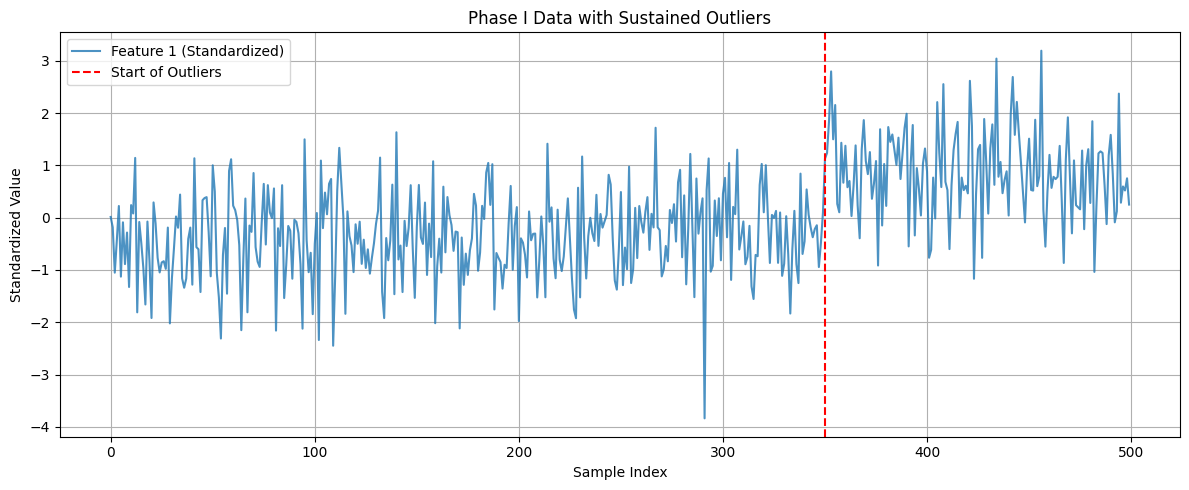

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_samples = 500             # Total Phase I samples
n_features = 150             # Number of features
outlier_start = 350         # Index to start sustained outliers
shift_magnitude = 1.5       # Magnitude of shift
shift_dims = 150              # Number of dimensions affected by shift

# Generate clean in-control Phase I data
X = np.random.normal(0, 1, size=(n_samples, n_features))

# Inject sustained shift (outliers)
X[outlier_start:, :shift_dims] += shift_magnitude

# Create labels (0 = in-control, 1 = outlier)
y = np.zeros(n_samples, dtype=int)
y[outlier_start:] = 1

# Standardize the full dataset
X = StandardScaler().fit_transform(X)

# Plot a shifted feature
plt.figure(figsize=(12, 5))
plt.plot(X[:, 0], label='Feature 1 (Standardized)', alpha=0.8)
plt.axvline(outlier_start, color='red', linestyle='--', label='Start of Outliers')
plt.title("Phase I Data with Sustained Outliers")
plt.xlabel("Sample Index")
plt.ylabel("Standardized Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
X

array([[ 0.01341285, -0.495823  ,  0.09426006, ..., -1.38755902,
         0.02496955, -0.07758594],
       [-0.18445418, -0.08530015, -1.00603623, ..., -0.06175879,
         0.26355411,  0.19787238],
       [-1.05194637, -0.85316154,  0.17680431, ..., -1.07758086,
        -0.82449917, -1.20063605],
       ...,
       [ 0.51964079,  0.23307776, -0.24480799, ...,  1.94309122,
         1.15693023,  0.03883791],
       [ 0.75179752,  0.59387633,  1.17333711, ...,  0.13617947,
         1.22453531,  1.32379066],
       [ 0.24984002,  1.25292766,  0.80258118, ...,  1.08515254,
         1.65419524,  0.77682953]])

In [27]:
vs = VSCOUT()
vs.fit(X)

Epoch 1/30
16/16 [==============================] - 0s 6ms/step - loss: 301.4552 - reconstruction_loss: 255.5802 - kl_loss: 45.8750
Epoch 2/30
16/16 [==============================] - 0s 5ms/step - loss: 293.2205 - reconstruction_loss: 249.4903 - kl_loss: 43.7302
Epoch 3/30
16/16 [==============================] - 0s 5ms/step - loss: 292.4555 - reconstruction_loss: 249.3580 - kl_loss: 43.0976
Epoch 4/30
16/16 [==============================] - 0s 5ms/step - loss: 286.5370 - reconstruction_loss: 243.7053 - kl_loss: 42.8317
Epoch 5/30
16/16 [==============================] - 0s 5ms/step - loss: 281.1490 - reconstruction_loss: 238.8855 - kl_loss: 42.2635
Epoch 6/30
16/16 [==============================] - 0s 5ms/step - loss: 277.2207 - reconstruction_loss: 236.0914 - kl_loss: 41.1293
Epoch 7/30
16/16 [==============================] - 0s 3ms/step - loss: 269.3192 - reconstruction_loss: 228.5280 - kl_loss: 40.7913
Epoch 8/30
16/16 [==============================] - 0s 4ms/step - loss: 266.

 1/16 [>.............................] - ETA: 0s

10/10 [==============================] - 0s 1000us/step


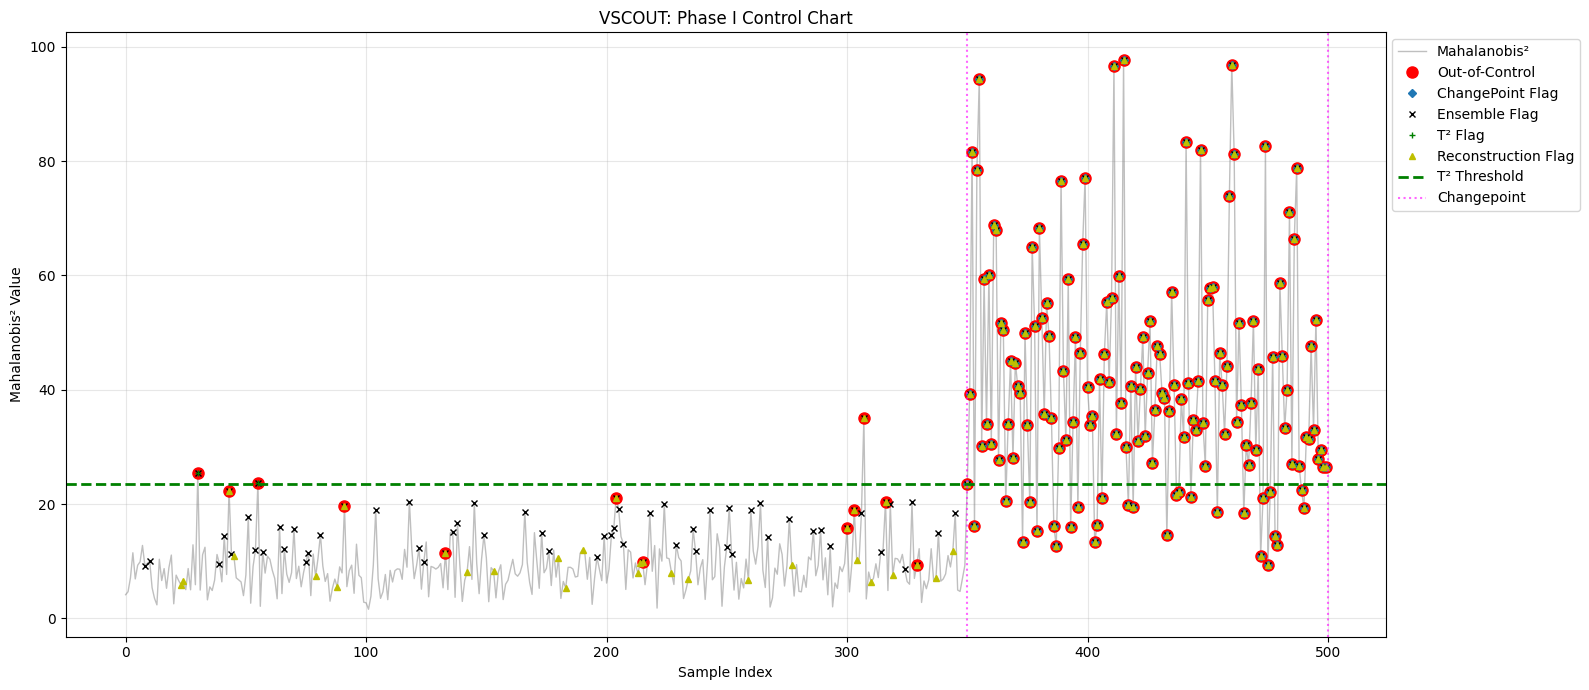

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [28]:
vs.plot_control_chart(X)

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score
# 2. Predict outliers on Phase I
is_out, *_ = vs.is_outlier(X)
y_pred = is_out.astype(int)

# 3. Evaluate performance
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

# 4. Print results
print("=== VSCOUT Phase I Performance ===")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f'False Positive Rate: {(np.sum((y == 0) & (y_pred == 1)) / np.sum(y == 0)):.4f}  ')

10/10 [==============================] - 0s 2ms/step
=== VSCOUT Phase I Performance ===
Precision: 0.9202
Recall:    1.0000
F1 Score:  0.9585
False Positive Rate: 0.0371  
